In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('retail sales.csv')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Filling missing values in 'Postal Code' column with 0

In [8]:
df['Postal Code'] = df['Postal Code'].fillna(0)

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### Checking duplicate value

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

### Convert Ship-Date and Order-Date

In [12]:
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

object
object


In [13]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

In [14]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


### Creating new Features

In [15]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month Number"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter

## Performing EDA

### 1. Sales Distribution

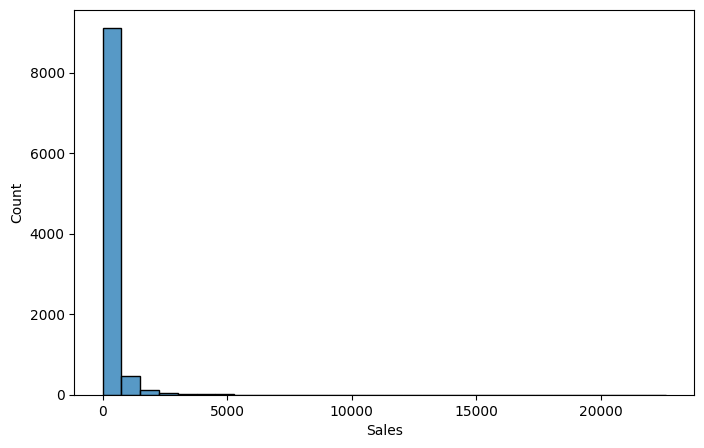

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=30)
plt.show()

### 2. Top Categories

<Axes: xlabel='Category'>

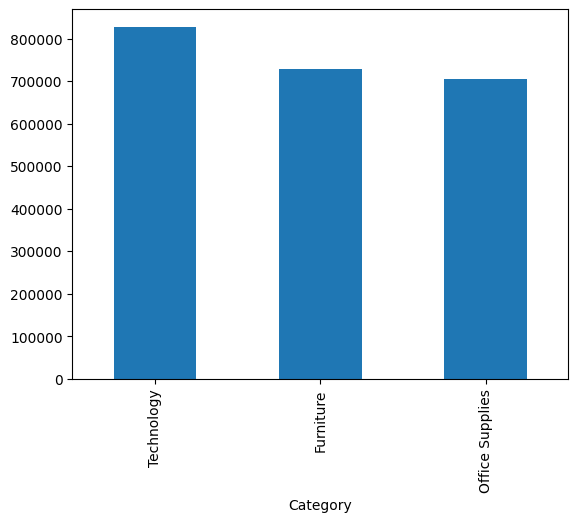

In [17]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)
category_sales.plot(kind="bar")

### 3. Top Sub Categories

<Axes: xlabel='Sub-Category'>

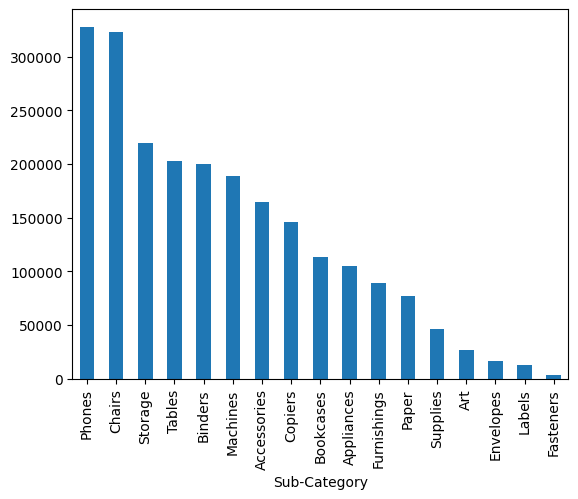

In [18]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)
subcategory_sales.plot(kind="bar")

### 4. Top Products

<Axes: ylabel='Product Name'>

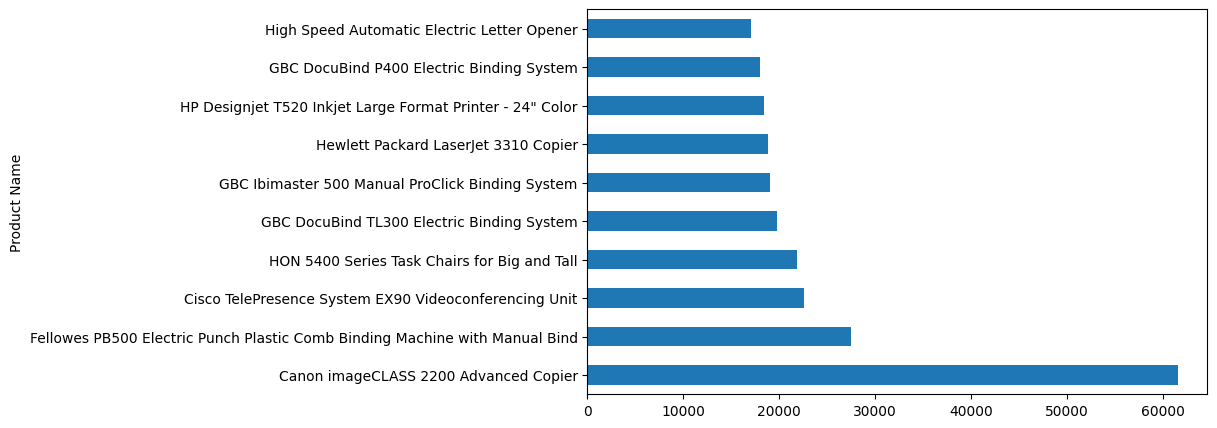

In [19]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_products.plot(kind="barh", figsize=(8,5))

### 5. Regional Analysis

<Axes: xlabel='Region'>

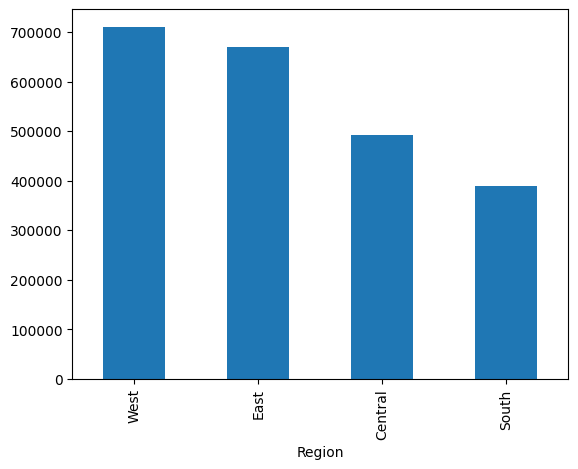

In [20]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)
region_sales.plot(kind="bar")

### 6. Customer Segment Analysis

<Axes: ylabel='Sales'>

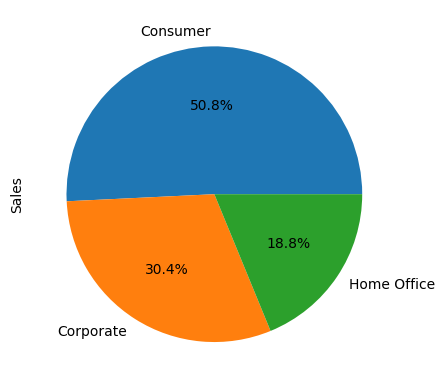

In [21]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
)
segment_sales.plot(kind="pie", autopct="%1.1f%%")

### 7. Shipping Mode Analysis

<Axes: xlabel='Ship Mode'>

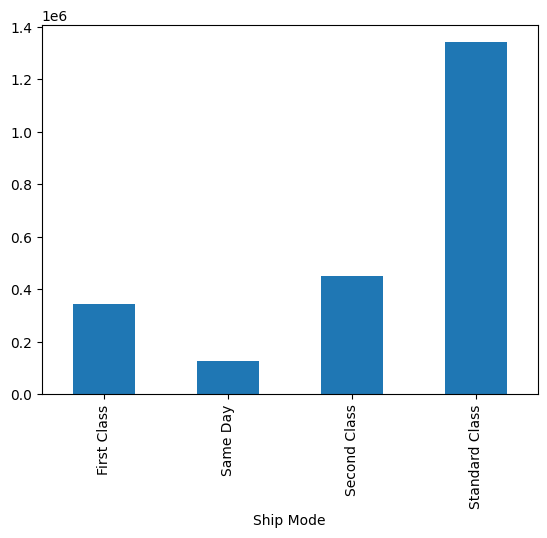

In [22]:
ship_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
)
ship_sales.plot(kind="bar")

### 8. Monthly Sales Trend

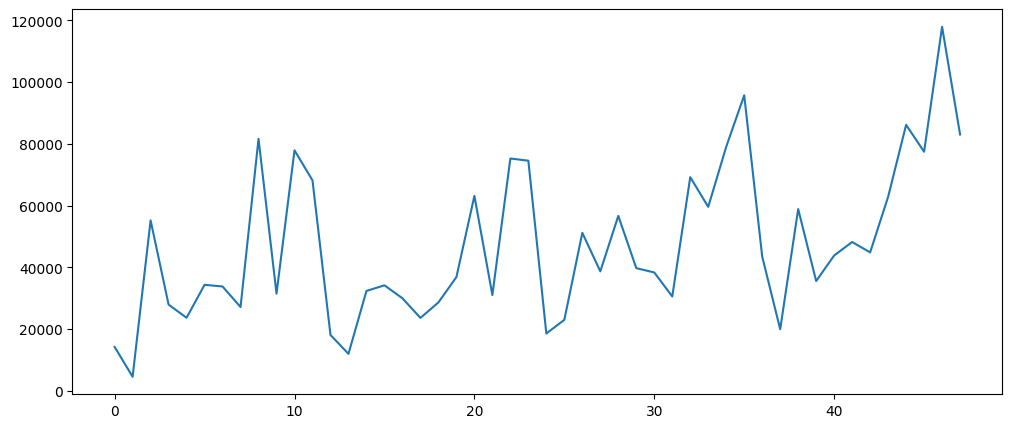

In [26]:
monthly_sales = (
    df.groupby(["Year","Month Number"])
      ["Sales"]
      .sum()
      .reset_index()
)
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Sales"])
plt.show()

### 9. Yearly Trend

<Axes: xlabel='Year'>

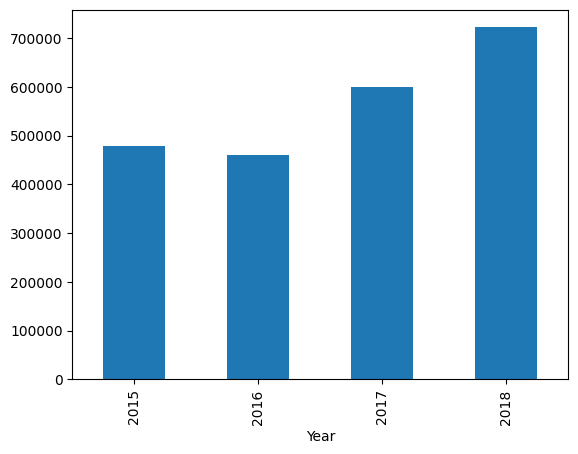

In [ ]:
yearly_sales = (
    df.groupby("Year")["Sales"]
      .sum()
)
yearly_sales.plot(kind="bar")

### 10. Correlation Analysis

<Axes: >

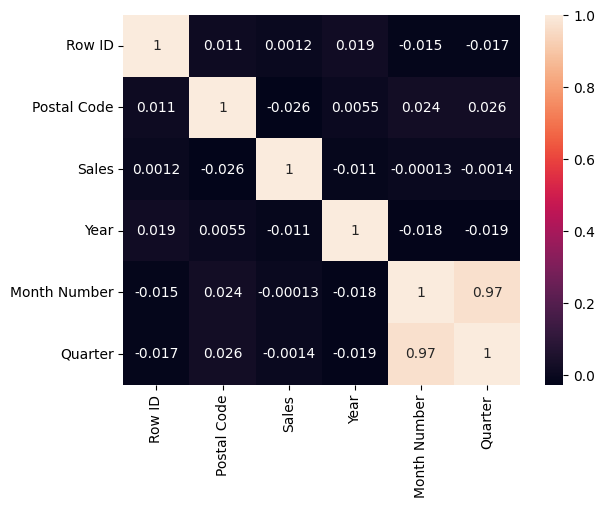

In [ ]:
df.select_dtypes(include="number").corr()
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True
)

### 11. Top Customers

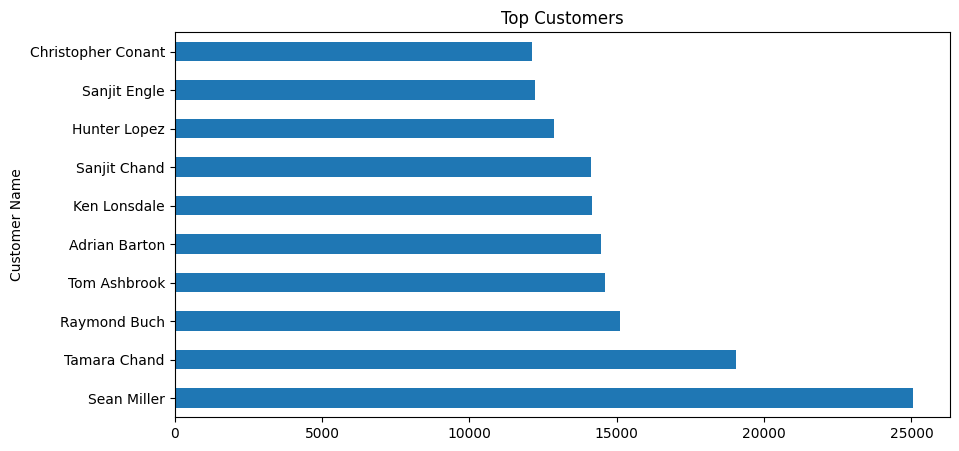

In [ ]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind="barh")
plt.title("Top Customers")
plt.show()

### 12. Customer Purchase Frequency

In [ ]:
customer_frequency = (
    df.groupby("Customer ID")
      .size()
      .sort_values(ascending=False)
)

customer_frequency.head(10)

Customer ID
WB-21850    35
PP-18955    34
MA-17560    34
JL-15835    33
CK-12205    32
JD-15895    32
SV-20365    32
EP-13915    31
ZC-21910    31
AP-10915    31
dtype: int64

### 13. Sales by Year and Category

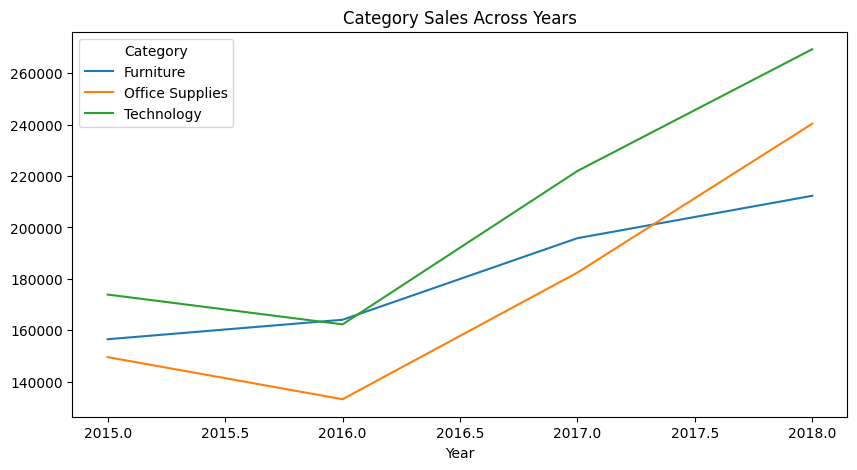

In [ ]:
sales_year_category = pd.pivot_table(
    df,
    values="Sales",
    index="Year",
    columns="Category",
    aggfunc="sum"
)

sales_year_category.plot(figsize=(10,5))
plt.title("Category Sales Across Years")
plt.show()

### 14. Sales by Segment and Category

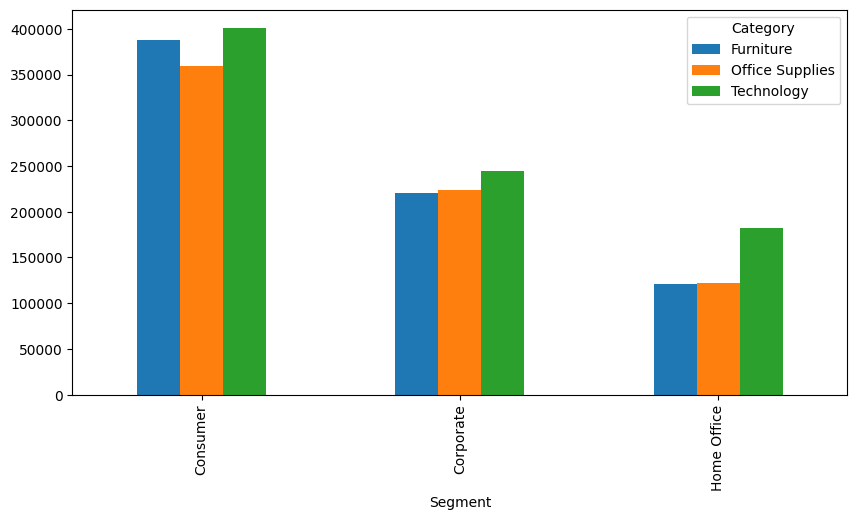

In [ ]:
segment_category = pd.pivot_table(
    df,
    values="Sales",
    index="Segment",
    columns="Category",
    aggfunc="sum"
)

segment_category.plot(kind="bar", figsize=(10,5))
plt.show()

## Creating RFM Table

In [ ]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,
    "Order ID": "count",
    "Sales": "sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,11,5563.560
AA-10375,20,15,1056.390
AA-10480,260,12,1790.512
AA-10645,56,18,5086.935
AB-10015,416,6,886.156


## RFM Scoring

In [ ]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
AA-10315,185,11,5563.560,2,2,4,224
AA-10375,20,15,1056.390,4,3,1,431
AA-10480,260,12,1790.512,1,3,2,132
AA-10645,56,18,5086.935,3,4,4,344
AB-10015,416,6,886.156,1,1,1,111


## Creating Customer Segment Based on the RFM Score

In [ ]:
def customer_segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"

    elif row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 3:
        return "Potential Loyalists"

    else:
        return "At Risk"


rfm["Customer_Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

In [ ]:
rfm["Customer_Segment"].value_counts()

Customer_Segment
Loyal Customers        327
At Risk                235
Potential Loyalists    162
Champions               69
Name: count, dtype: int64

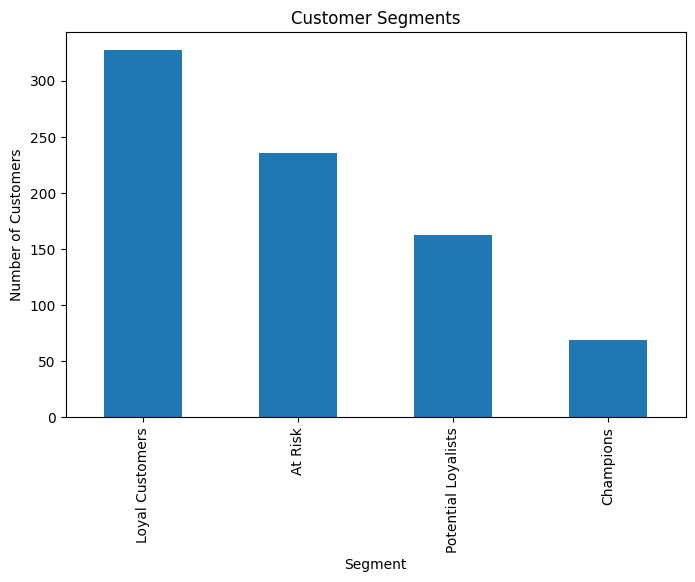

In [ ]:
rfm["Customer_Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
segment_revenue = rfm.groupby(
    "Customer_Segment"
)["Monetary"].sum()

segment_revenue

Customer_Segment
At Risk                3.480799e+05
Champions              2.866810e+05
Loyal Customers        1.302709e+06
Potential Loyalists    3.240664e+05
Name: Monetary, dtype: float64

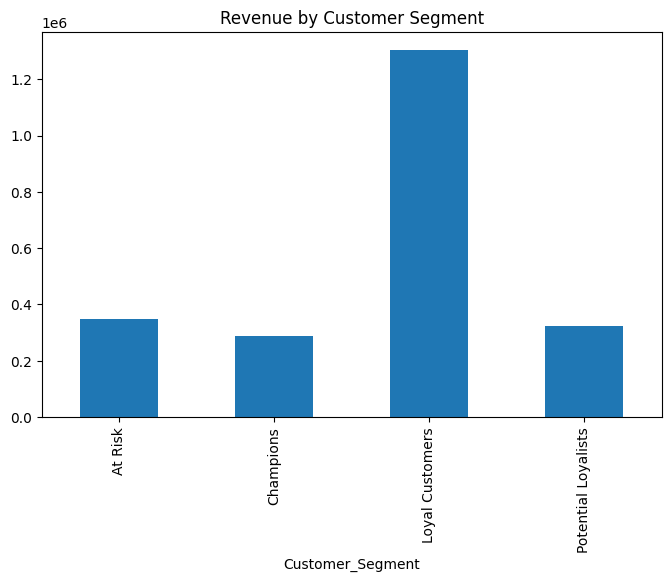

In [ ]:
segment_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Customer Segment")
plt.show()

In [ ]:
df.to_csv("Retail_Cleaned.csv", index=False)